# Tarea — Unidad 4 · Preparación de datos para un modelo de riesgo de ictus (accidente cerebrovascular)

**FP13 · Inteligencia Artificial · UAG**
Subtemas 4.1 a 4.7

---

## Contexto

El **Stroke Prediction Dataset** contiene 5,110 registros de pacientes con 11 variables clínicas y
sociodemográficas. El desenlace `stroke` indica si el paciente presentó un evento cerebrovascular.

En la Práctica 7 trabajamos cada transformación por separado sobre datos de cardiopatía isquémica.
Aquí el encargo es distinto: **construir una matriz de modelado completa**, desde el archivo crudo
hasta la selección final de variables, y **justificar una decisión por columna**.

## Qué se evalúa

No se evalúa que el código corra: se evalúa que **cada decisión esté argumentada con evidencia
producida por usted**.

| Criterio | Peso |
|---|---|
| Corrección técnica del código (partes 1 a 9) | 40 % |
| Justificación escrita de cada decisión | 30 % |
| Tabla de decisiones por columna (Parte 10) | 15 % |
| Preguntas de reflexión | 15 % |

## Entrega

Este mismo notebook **ejecutado de arriba a abajo sin errores**, con todas las celdas de texto
completadas. Nombre el archivo `Tarea_U4_ApellidoNombre.ipynb`.

## Restricciones

- **No use `Pipeline` ni `ColumnTransformer`.** Todo se resuelve columna por columna, de forma
  explícita. Volveremos a encapsularlo en la Unidad 5.
- Fije la semilla al inicio y no la vuelva a tocar.
- Toda afirmación sobre los datos debe estar respaldada por una celda que la produzca.

---
## Parte 0 · Preparación

In [1]:
# [1] Entorno y semilla
# TODO: importe numpy, pandas, matplotlib.pyplot y scipy.stats.
#       Fije SEED = 42 y configure la salida de pandas.
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import scipy.stats as stats
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
# [2] Ingesta del conjunto de datos
# TODO: cargue "healthcare-dataset-stroke-data.csv" en un DataFrame llamado df.
#       Puede usar kagglehub (dataset "fedesoriano/stroke-prediction-dataset") (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
#       o la copia local. Imprima la forma y las primeras filas.
import os
if os.path.exists("healthcare-dataset-stroke-data.csv"):
    ruta = "healthcare-dataset-stroke-data.csv"
else:
    import kagglehub
    ruta = os.path.join(kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset"),
                        "healthcare-dataset-stroke-data.csv")
df = pd.read_csv(ruta)
print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1
1,51676,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,NaN,never smoked,1
2,31112,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1
3,60182,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1
4,1665,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1


---
## Parte 1 · Reconocimiento (subtema 4.7)

Antes de modificar nada hay que saber qué se tiene. La clasificación de una variable en nominal,
binaria o numérica es una decisión **clínica**, no estadística: la toma usted, no `pandas`.

In [3]:
# [3] Inventario de columnas
# TODO: construya una tabla con, por columna: tipo de dato, numero de valores unicos,
#       numero de nulos y porcentaje de nulos.
inventario = pd.DataFrame({
    "dtype": df.dtypes,
    "unicos": df.nunique(),
    "nulos": df.isna().sum(),
    "pct_nulos": df.isna().mean() * 100,
})
inventario

,dtype,unicos,nulos,pct_nulos
id,int64,5110,0,0.0000
gender,str,3,0,0.0000
age,float64,104,0,0.0000
hypertension,int64,2,0,0.0000
heart_disease,int64,2,0,0.0000
ever_married,str,2,0,0.0000
work_type,str,5,0,0.0000
Residence_type,str,2,0,0.0000
avg_glucose_level,float64,3979,0,0.0000
bmi,float64,418,201,3.9335


In [4]:
# [4] Declaracion de roles
# TODO: defina las listas IDENT, NOMINALES, BINARIAS, INDICADOR, NUMERICAS y OBJETIVO.
#       Imprima las categorias de cada variable de texto con su frecuencia,
#       la prevalencia del objetivo y cuantos valores unicos toma la columna de folio.

IDENT     = "id"
NOMINALES = ["gender", "work_type", "smoking_status"]   # sin orden intrinseco
BINARIAS  = ["ever_married", "Residence_type"]          # dos categorias de texto
INDICADOR = ["hypertension", "heart_disease"]           # ya vienen como 0/1
NUMERICAS = ["age", "avg_glucose_level", "bmi"]
OBJETIVO  = "stroke"

print("Categorias de cada variable de texto:")
for c in NOMINALES + BINARIAS:
    print(f"  {c:<16} {dict(df[c].value_counts())}")

print(f"\nPrevalencia de ictus: {df[OBJETIVO].mean():.4f}")
print(f"Folios unicos: {df[IDENT].nunique()} de {len(df)} filas")

Categorias de cada variable de texto:
  gender           {'Female': np.int64(2994), 'Male': np.int64(2115), 'Other': np.int64(1)}
  work_type        {'Private': np.int64(2925), 'Self-employed': np.int64(819), 'children': np.int64(687), 'Govt_job': np.int64(657), 'Never_worked': np.int64(22)}
  smoking_status   {'never smoked': np.int64(1892), 'Unknown': np.int64(1544), 'formerly smoked': np.int64(885), 'smokes': np.int64(789)}
  ever_married     {'Yes': np.int64(3353), 'No': np.int64(1757)}
  Residence_type   {'Urban': np.int64(2596), 'Rural': np.int64(2514)}

Prevalencia de ictus: 0.0487
Folios unicos: 5110 de 5110 filas


**Responda antes de continuar.** Dos columnas categóricas contienen algo que no debería estar ahí:
una tiene una categoría con un solo paciente, otra tiene una categoría que no describe ninguna
condición clínica. Identifíquelas.

*Su respuesta:*

- **`gender`**: la categoría `Other` tiene un solo paciente (celda [4]). Con n = 1 no se puede estimar ningún efecto y, al codificarla, produce una columna con un único 1.
- **`smoking_status`**: la categoría `Unknown` (1,544 registros) no describe una condición clínica (no es fumador, ex fumador ni no fumador): significa «dato no disponible». Es un faltante disfrazado de texto y por eso no aparece en `isna()`; se trata en la Parte 3.

---
## Parte 2 · Integridad de los registros: duplicados (subtema 4.7)

Eliminar duplicados es un paso obligatorio del protocolo. Pero *duplicado* no significa «filas
parecidas»: significa **el mismo paciente capturado dos veces**. Verifique en tres niveles **antes**
de borrar una sola fila.

In [5]:
# [5] Tres niveles de verificacion
# TODO: cuente (1) duplicados exactos sobre todas las columnas,
#       (2) duplicados ignorando la columna de folio,
#       (3) filas que repiten una llave clinica formada por las categoricas + age.
#       Reporte cuantas filas y cuantos perfiles distintos involucra el nivel 3.
llave_clinica = NOMINALES + BINARIAS + ["age"]

n1 = df.duplicated().sum()
n2 = df.drop(columns=IDENT).duplicated().sum()
rep = df[df.duplicated(subset=llave_clinica, keep=False)]
print(f"Nivel 1 - duplicados exactos (todas las columnas):   {n1}")
print(f"Nivel 2 - duplicados ignorando el folio:              {n2}")
print(f"Nivel 3 - filas que repiten la llave clinica:         {len(rep)}")
print(f"          perfiles distintos involucrados:            {rep.groupby(llave_clinica).ngroups}")

Nivel 1 - duplicados exactos (todas las columnas):   0
Nivel 2 - duplicados ignorando el folio:              0
Nivel 3 - filas que repiten la llave clinica:         3818
          perfiles distintos involucrados:            1141


In [6]:
# [6] La prueba decisiva
# TODO: repita el conteo del nivel 3 agregando bmi y avg_glucose_level a la llave.
#       Muestre dos registros con el mismo perfil clinico y mediciones distintas.
#       Decida: que filas elimina y que columnas elimina. Ejecute su decision.
llave_fina = llave_clinica + ["bmi", "avg_glucose_level"]
print("Nivel 3 + bmi + glucosa -> filas repetidas:", df.duplicated(subset=llave_fina, keep=False).sum())

print("\nDos registros con el mismo perfil clinico y mediciones distintas:")
print(df[df.duplicated(subset=llave_clinica, keep=False)].sort_values(llave_clinica).head(2))

borraria = df.duplicated(subset=llave_clinica)
print(f"\ndrop_duplicates(subset=llave_clinica) borraria {borraria.sum()} filas ({borraria.mean():.1%}), "
      f"entre ellas {df.loc[borraria, OBJETIVO].sum()} casos de ictus")
print("Perfiles clinicos cuyos miembros NO comparten desenlace:",
      (rep.groupby(llave_clinica)[OBJETIVO].nunique() > 1).sum())

# Decision: 0 filas eliminadas; se elimina la columna de folio.
df = df.drop(columns=IDENT)
print("\nFilas eliminadas: 0 | Columna eliminada:", IDENT, "| forma:", df.shape)

Nivel 3 + bmi + glucosa -> filas repetidas: 0

Dos registros con el mismo perfil clinico y mediciones distintas:
         id  gender     age  hypertension  heart_disease ever_married  \
2586  41175  Female 22.0000             0              0           No   
4306  34415  Female 22.0000             0              0           No   

     work_type Residence_type  avg_glucose_level     bmi smoking_status  \
2586  Govt_job          Urban           123.2300 21.3000        Unknown   
4306  Govt_job          Urban            79.5700 31.8000        Unknown   

      stroke  
2586       0  
4306       0  

drop_duplicates(subset=llave_clinica) borraria 2677 filas (52.4%), entre ellas 16 casos de ictus
Perfiles clinicos cuyos miembros NO comparten desenlace: 161

Filas eliminadas: 0 | Columna eliminada: id | forma: (5110, 11)


**Justifique su decisión.** ¿Cuántas filas eliminó y por qué? Si eliminó cero, dígalo
explícitamente y explique qué habría pasado con `drop_duplicates(subset=llave_clinica)`. Si eliminó
alguna columna, justifique por qué no aporta al modelo.

*Su respuesta:*

**No eliminé ninguna fila.** Sí eliminé una columna: `id`.

- Niveles 1 y 2: 0 duplicados exactos y 0 ignorando el folio (celda [5]). No hay ningún registro capturado dos veces.
- Nivel 3: 3,818 filas repiten la llave clínica (categóricas + `age`), agrupadas en 1,141 perfiles. Parece un problema, pero la llave tiene muy pocas combinaciones posibles (tres nominales, dos binarias y una edad en años), así que es normal que muchas personas distintas coincidan.
- La prueba decisiva (celda [6]): al añadir `bmi` y `avg_glucose_level` a la llave, las filas repetidas bajan a **0**. Los dos registros mostrados (mujer de 22 años, soltera, `Govt_job`, `Urban`, `Unknown`) tienen glucosa de 123.23 y 79.57 mg/dL y bmi de 21.3 y 31.8: son dos personas distintas, no el mismo paciente capturado dos veces.
- Con `drop_duplicates(subset=llave_clinica)` habría borrado 2,677 filas (52.4 % del conjunto), incluidos 16 casos de ictus, y en 161 perfiles los miembros no comparten desenlace, así que habría conservado uno al azar y descartado el otro. Habría destruido más de la mitad de los datos por confundir «perfil parecido» con «mismo paciente».
- **Columna `id`:** 5,110 folios únicos en 5,110 filas, es decir, un número de registro sin contenido clínico. Ninguna asociación real puede depender de él; dejarlo solo introduce ruido y riesgo de que el modelo memorice registros. Por eso se elimina (forma final: 5,110 × 11).

---
## Parte 3 · Valores faltantes: los declarados y los enmascarados

En la Práctica 7 el faltante se disfrazaba de número (colesterol = 0 mg/dL). Aquí hay faltantes de
dos tipos y uno de ellos se disfraza de **texto**.

In [7]:
# [7] Faltantes declarados y enmascarados
# TODO: (a) reporte los nulos declarados por columna.
#       (b) localice la categoria de texto que en realidad significa "dato no disponible"
#           y cuente cuantos registros la tienen.
#       (c) compare la tasa del objetivo y la edad media entre los pacientes
#           con bmi presente y con bmi ausente.
print("(a) Nulos declarados:")
print(df.isna().sum()[lambda s: s > 0])

es_unk = df["smoking_status"] == "Unknown"
print(f"\n(b) smoking_status == 'Unknown': {es_unk.sum()} registros ({es_unk.mean():.1%})")

print("\n(c) bmi presente vs ausente:")
print(df.groupby(df["bmi"].isna().map({False: "presente", True: "ausente"}))
        .agg(n=("stroke", "size"), tasa_ictus=("stroke", "mean"), edad_media=("age", "mean")))

(a) Nulos declarados:
bmi    201
dtype: int64

(b) smoking_status == 'Unknown': 1544 registros (30.2%)

(c) bmi presente vs ausente:
             n  tasa_ictus  edad_media
bmi                                   
ausente    201      0.1990     52.0492
presente  4909      0.0426     42.8654


**Interprete (c).** ¿El dato de `bmi` falta al azar? Si su respuesta es no, proponga un mecanismo
clínico que lo explique y diga qué consecuencia tiene para la imputación.

*Su respuesta:*

**No, `bmi` no falta al azar.** Los 201 pacientes sin `bmi` tienen una tasa de ictus de 19.9 % frente a 4.3 % en los 4,909 que sí lo tienen (casi cinco veces más), y además son mayores (edad media 52.0 vs 42.9 años).

Mecanismo clínico plausible: calcular el IMC exige pesar y medir al paciente. A quien llega grave, inmovilizado o en urgencia por un evento cerebrovascular (hemiparesia, encamado, atención de emergencia) no se le toma o no se le registra ese dato. El faltante depende entonces de la gravedad, y por tanto del desenlace: el ictus «causa» el faltante y no al revés.

Consecuencia para la imputación: si se rellena con un valor típico se fabrica un dato «normal» justo en el grupo de mayor riesgo y se borra la señal. Hay que (1) marcar el faltante en una columna indicadora antes de imputar y (2) condicionar la imputación por edad y sexo, porque el grupo con faltantes no tiene la misma composición que el resto.

In [8]:
# [8] Mecanismo del faltante enmascarado
# TODO: calcule la proporcion de la categoria enmascarada segun work_type
#       y segun grupo de edad (use pd.cut con cortes 0-18-40-60-120).
#       Concluya si el patron es aleatorio.
df["grupo_edad"] = pd.cut(df["age"], bins=[0, 18, 40, 60, 120], labels=["0-18", "18-40", "40-60", "60+"])

print("Proporcion de 'Unknown' segun work_type:")
print(es_unk.groupby(df["work_type"]).mean().round(3))
print("\nProporcion de 'Unknown' segun grupo de edad:")
print(es_unk.groupby(df["grupo_edad"], observed=True).agg(n="size", proporcion="mean").round(3))

Proporcion de 'Unknown' segun work_type:
work_type
Govt_job        0.1860
Never_worked    0.3640
Private         0.2190
Self-employed   0.1900
children        0.9000
Name: smoking_status, dtype: float64

Proporcion de 'Unknown' segun grupo de edad:
               n  proporcion
grupo_edad                  
0-18         916      0.7740
18-40       1328      0.2170
40-60       1562      0.1950
60+         1304      0.1860


Mediana global de bmi: 28.1
Mediana de bmi por grupo de edad y sexo:
grupo_edad  gender
0-18        Female   20.4000
            Male     20.0000
18-40       Female   27.6000
            Male     28.4000
            Other    22.4000
40-60       Female   29.8000
            Male     30.9000
60+         Female   29.1000
            Male     29.1000
Name: bmi, dtype: float64
                     n   media  desv_est  asimetria
observados   4909.0000 28.8932    7.8541     1.0550
global       5110.0000 28.8620    7.6996     1.0879
condicionada 5110.0000 28.8708    7.7205     1.0699


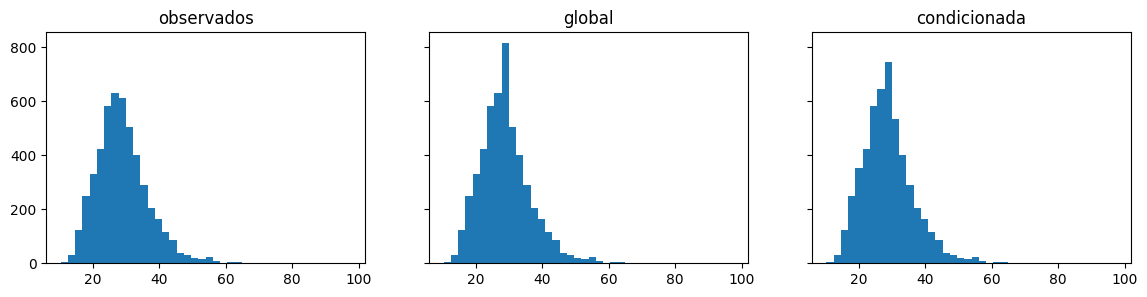

Nulos restantes en bmi: 0


In [9]:
# [9] Imputacion de bmi
# TODO: (a) cree la columna indicadora bmi_faltante ANTES de imputar.
#       (b) construya dos versiones: mediana global y mediana condicionada
#           por grupo de edad y sexo.
#       (c) compare n, media, desviacion estandar y asimetria de las tres versiones
#           (observados, global, condicionada) e incluya un histograma de cada imputacion.
#       (d) elija una, aplíquela a df y verifique que no quedan nulos.
df["bmi_faltante"] = df["bmi"].isna().astype(int)                                   # (a)
print("Mediana global de bmi:", df["bmi"].median())
print("Mediana de bmi por grupo de edad y sexo:")
print(df.groupby(["grupo_edad", "gender"], observed=True)["bmi"].median())

bmi_global = df["bmi"].fillna(df["bmi"].median())                                   # (b) mediana global
bmi_cond = df["bmi"].fillna(                                                        # (b) mediana por edad y sexo
    df.groupby(["grupo_edad", "gender"], observed=True)["bmi"].transform("median"))

versiones = {"observados": df["bmi"].dropna(), "global": bmi_global, "condicionada": bmi_cond}
print(pd.DataFrame({k: {"n": len(v), "media": v.mean(), "desv_est": v.std(), "asimetria": stats.skew(v)}
                    for k, v in versiones.items()}).T)                              # (c)

fig, ax = plt.subplots(1, 3, figsize=(14, 3), sharex=True, sharey=True)
for a, (k, v) in zip(ax, versiones.items()):
    a.hist(v, bins=40)
    a.set_title(k)
plt.show()

df["bmi"] = bmi_cond                                                                # (d)
print("Nulos restantes en bmi:", df["bmi"].isna().sum())

**Justifique su elección.** ¿Qué le pasa a la desviación estándar al imputar y por qué? ¿Qué aporta
`bmi_faltante` que la imputación por sí sola pierde? ¿Y qué decidió hacer con la categoría
enmascarada de la celda [8] — imputarla o conservarla? Argumente.

*Su respuesta:*

**Celda [8] (¿el patrón enmascarado es aleatorio?).** No. La proporción de `Unknown` es de 90.0 % en `work_type = children` y de 77.4 % en el grupo de 0-18 años, frente a 18.6-21.7 % en los tres grupos de adultos y entre 18.6 % y 21.9 % en los demás tipos de trabajo (`Never_worked` llega a 36.4 %, pero son solo 22 pacientes). El patrón está concentrado en menores: en buena parte es «no aplica / no se preguntó», no un olvido al azar.

**Elección de imputación.** Elijo la **mediana condicionada por grupo de edad y sexo**. El `bmi` cambia mucho con la edad (los menores tienen valores muy distintos a los adultos), así que la mediana global (28.1) asigna a un niño un valor de adulto con sobrepeso. La condicionada conserva mejor la distribución: media 28.871 (observados: 28.893) y asimetría 1.070 (observados: 1.055), frente a 28.862 y 1.088 de la global.

**Desviación estándar.** Baja al imputar: de 7.854 (observados) a 7.720 (condicionada) y a 7.700 (global). Los 201 valores imputados se colocan en el centro de su grupo, es decir, a distancia casi cero de la media, y esos puntos adicionales reducen la dispersión aparente sin aportar información nueva. La condicionada la reduce menos porque reparte los valores por grupos.

**Qué aporta `bmi_faltante`.** Conserva el hecho de que el dato faltaba, que es en sí mismo informativo (tasa de ictus de 19.9 % vs 4.3 %). La imputación por sí sola borra esa información: tras imputar, un paciente con `bmi` inventado es indistinguible de uno medido. En la celda [20] tiene correlación de 0.141 con el objetivo, mayor que la de `bmi` (0.040).

**Categoría enmascarada `Unknown`: la conservo como categoría propia y no la imputo.** Es un faltante en gran parte estructural (77.4 % en menores). Imputar un estado de tabaquismo en 1,544 pacientes (30.2 %) asignaría «no fumador» o «fumador» a niños y fabricaría datos. Como categoría, el modelo puede aprender de ella (se codifica como `smoking_status_Unknown`).

---
## Parte 4 · Valores atípicos (subtema 4.3)

                   lim_inf  lim_sup  n_atipicos   maximo
age               -29.0000 115.0000           0  82.0000
avg_glucose_level  21.9775 169.3575         627 271.7400
bmi                10.0500  46.4500         123  97.6000


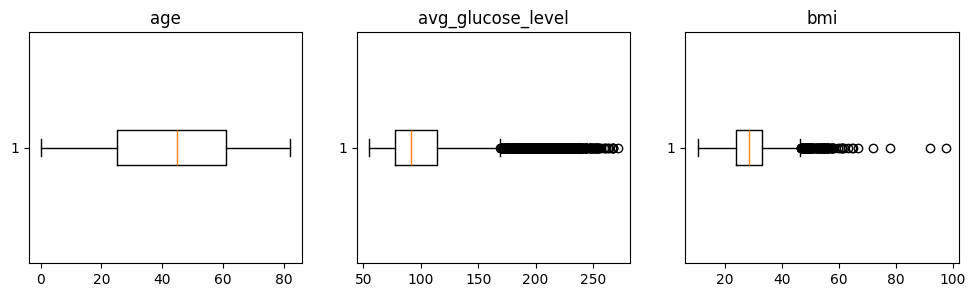

In [10]:
# [10] Deteccion por rango intercuartil
# TODO: escriba una funcion limites_iqr(x, k=1.5) que devuelva (Q1-k*IQR, Q3+k*IQR).
#       Aplíquela a las tres numericas: reporte limites, numero de atipicos y maximo.
#       Acompane con un diagrama de caja por variable.
def limites_iqr(x, k=1.5):
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

filas = {}
for c in NUMERICAS:
    lo, hi = limites_iqr(df[c])
    filas[c] = {"lim_inf": lo, "lim_sup": hi, "n_atipicos": ((df[c] < lo) | (df[c] > hi)).sum(), "maximo": df[c].max()}
print(pd.DataFrame(filas).T.astype({"n_atipicos": int}))

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, c in zip(ax, NUMERICAS):
    a.boxplot(df[c], vert=False)
    a.set_title(c)
plt.show()

In [11]:
# [11] Un atipico no es automaticamente un error
# TODO: para bmi, compare la tasa del objetivo dentro y fuera del limite superior.
#       Cuente los registros con bmi > 60 y reporte el maximo observado.
#       Calcule la asimetria antes y despues de una winsorizacion al percentil 99.
for c in ["bmi", "avg_glucose_level"]:
    lo, hi = limites_iqr(df[c])
    fuera = df[c] > hi
    print(f"{c:<18} tasa de ictus con {c} > {hi:.2f}: {df.loc[fuera, OBJETIVO].mean():.4f} (n={fuera.sum()}) | "
          f"dentro del limite: {df.loc[~fuera, OBJETIVO].mean():.4f}")

print(f"\nbmi > 60: {(df['bmi'] > 60).sum()} registros, con {df.loc[df['bmi'] > 60, OBJETIVO].sum()} casos de ictus | "
      f"maximo observado: {df['bmi'].max()}")
p99 = df["bmi"].quantile(0.99)
print(f"Asimetria de bmi: original {stats.skew(df['bmi']):.3f} | winsorizada al p99 ({p99:.2f}): "
      f"{stats.skew(df['bmi'].clip(upper=p99)):.3f}")

bmi                tasa de ictus con bmi > 46.45: 0.0244 (n=123) | dentro del limite: 0.0493
avg_glucose_level  tasa de ictus con avg_glucose_level > 169.36: 0.1340 (n=627) | dentro del limite: 0.0368

bmi > 60: 13 registros, con 0 casos de ictus | maximo observado: 97.6
Asimetria de bmi: original 1.070 | winsorizada al p99 (52.89): 0.674


**Decida y justifique.** ¿Elimina, recorta o conserva los atípicos de `bmi`? Compare este caso con
los ceros de colesterol de la Práctica 7: ¿por qué allá la decisión fue inmediata y aquí no?
Anticipe qué implica su decisión para la Parte 8.

*Su respuesta:*

**Decisión: conservo los atípicos de `bmi` (y los de glucosa); no los elimino ni los recorto.**

- No hay evidencia de que sean errores: 123 pacientes superan el límite de 46.45, 13 tienen `bmi > 60` y el máximo es 97.6. Son valores extremos, pero fisiológicamente posibles (obesidad mórbida). La tasa de ictus dentro de esa zona (2.4 %) es menor que fuera (4.9 %), es decir, no aportan una señal de riesgo, pero tampoco hay razón para tratarlos como fallas de captura (ninguno de los 13 con `bmi > 60` tuvo ictus).
- Winsorizar al percentil 99 (52.89) modificaría 1 % de los valores reales y solo baja la asimetría de 1.070 a 0.674. La transformación logarítmica de la Parte 7 la lleva a 0.02 sin alterar ninguna observación. Además, recortar convierte una medición en una estimación.
- En glucosa (627 valores sobre 169.36) la cola *es* la señal: la tasa de ictus es 13.4 % en la cola y 3.7 % fuera. Eliminarla borraría a los pacientes diabéticos.

**Comparación con los ceros de colesterol de la Práctica 7.** Allá un colesterol de 0 mg/dL es imposible: es un error seguro, un centinela numérico que se reconoce y se corrige de inmediato. Aquí un `bmi` de 97.6 es extremo pero posible; ser atípico estadísticamente no equivale a ser un error, y la decisión exige juicio clínico y evidencia.

**Implicación para la Parte 8.** Como conservo los extremos, el escalador no puede depender de ellos: necesito uno basado en mediana y rango intercuartil (`RobustScaler`), y aplicar antes el logaritmo a `bmi`.

---
## Parte 5 · Ingeniería de funciones (subtema 4.2)

Hasta aquí sólo ha limpiado. Ahora **agregue** información que el modelo no deduciría solo, usando
umbrales clínicos establecidos —no cortes arbitrarios.

In [12]:
# [12] Variables derivadas con criterio clinico
# TODO: construya al menos cuatro variables nuevas. Se sugieren:
#         - imc_cat        : clasificacion de la OMS (18.5 / 25 / 30 kg/m2)
#         - glucosa_cat    : umbrales de glucemia casual (140 / 200 mg/dL)
#         - n_comorbilidades : suma de hipertension y cardiopatia
#         - grupo_edad     : el que definio en la celda [8]
#       Para cada una, reporte el conteo y la tasa del objetivo por categoria.
#       Revise si la tasa es monotona en todas: una de ellas NO lo es.
df["imc_cat"] = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, np.inf], right=False,
                       labels=["Bajo peso", "Normal", "Sobrepeso", "Obesidad"])
df["glucosa_cat"] = pd.cut(df["avg_glucose_level"], bins=[0, 140, 200, np.inf], right=False,
                           labels=["Normal", "Elevada", "Rango diabetico"])
df["n_comorbilidades"] = df["hypertension"] + df["heart_disease"]

for c in ["imc_cat", "glucosa_cat", "n_comorbilidades", "grupo_edad"]:
    print(df.groupby(c, observed=True).agg(n=("stroke", "size"), tasa_ictus=("stroke", "mean"), edad_media=("age", "mean")), "\n")

              n  tasa_ictus  edad_media
imc_cat                                
Bajo peso   337      0.0030     10.9088
Normal     1264      0.0285     33.3275
Sobrepeso  1558      0.0700     49.9987
Obesidad   1951      0.0528     49.8144 

                    n  tasa_ictus  edad_media
glucosa_cat                                  
Normal           4289      0.0364     40.8151
Elevada           387      0.0956     49.3156
Rango diabetico   434      0.1290     61.6290 

                     n  tasa_ictus  edad_media
n_comorbilidades                              
0                 4400      0.0339     39.9061
1                  646      0.1347     63.1331
2                   64      0.2031     70.5781 

               n  tasa_ictus  edad_media
grupo_edad                              
0-18         916      0.0022      9.1790
18-40       1328      0.0045     30.1318
40-60       1562      0.0410     50.7177
60+         1304      0.1357     71.5061 



**Justifique los umbrales.** Cite el criterio clínico de cada corte. ¿Alguna de sus derivadas es
monótona respecto de la tasa del objetivo? ¿Y cuál de ellas es una discretización de una variable
que **ya tiene** en la matriz? Anótelo: va a importar en la Parte 9.

*Su respuesta:*

**Umbrales y criterio clínico.**

- `imc_cat`: clasificación de la OMS del índice de masa corporal: < 18.5 bajo peso, 18.5-24.9 normal, 25-29.9 sobrepeso, ≥ 30 obesidad (intervalos cerrados por la izquierda, con `right=False`).
- `glucosa_cat`: 140 y 200 mg/dL, los umbrales clásicos de la ADA y la OMS: < 140 normal, 140-199 elevada (rango de tolerancia alterada a la glucosa / prediabetes) y ≥ 200 rango compatible con diabetes. Se aplican como aproximación, porque `avg_glucose_level` es un promedio y no una medición casual aislada.
- `n_comorbilidades`: suma de hipertensión y cardiopatía (0, 1 o 2); no requiere umbral.
- `grupo_edad`: los cortes 18-40-60 de la celda [8] (menores, adulto joven, adulto medio y persona mayor a partir de 60 años).

**Monotonía.** Son monótonas `grupo_edad` (0.2 %, 0.5 %, 4.1 %, 13.6 %), `glucosa_cat` (3.6 %, 9.6 %, 12.9 %) y `n_comorbilidades` (3.4 %, 13.5 %, 20.3 %). **`imc_cat` NO lo es:** 0.3 %, 2.8 %, 7.0 % y 5.3 %; obesidad tiene menor tasa que sobrepeso. No se explica por la edad, porque ambos grupos tienen edad media casi idéntica (50.0 y 49.8 años): la relación entre `bmi` e ictus es no monótona en estos datos.

**Qué va a importar en la Parte 9.** Tres derivadas son discretizaciones de una variable continua que ya está en la matriz: `grupo_edad` (de `age`), `imc_cat` (de `bmi`) y `glucosa_cat` (de `avg_glucose_level`). La cuarta, `n_comorbilidades`, no discretiza nada: es la suma exacta de dos columnas que ya tengo (`hypertension` y `heart_disease`).

---
## Parte 6 · Codificación one-hot (subtema 4.4)

In [13]:
# [13] One-hot y el efecto del parametro drop
# TODO: con OneHotEncoder, compare el numero de columnas resultante con
#       drop=None, drop="first" y drop="if_binary".
#       Ajuste la version que elija, construya la matriz codificada y reporte su forma.
#       Identifique la columna con menor frecuencia y cuantos registros la activan.
from sklearn.preprocessing import OneHotEncoder

CATEG = NOMINALES + BINARIAS + ["imc_cat", "glucosa_cat", "grupo_edad"]
for d in [None, "first", "if_binary"]:
    e = OneHotEncoder(drop=d, sparse_output=False).fit(df[CATEG].astype(str))
    print(f"drop={str(d):<10} -> {len(e.get_feature_names_out())} columnas")

enc = OneHotEncoder(drop="if_binary", sparse_output=False)
oh = pd.DataFrame(enc.fit_transform(df[CATEG].astype(str)), columns=enc.get_feature_names_out(CATEG), index=df.index)
print("\nForma de la matriz codificada:", oh.shape)
frec = oh.sum().sort_values()
print(frec.head(3))
print(f"Columna menos frecuente: {frec.index[0]} ({int(frec.iloc[0])} registros)")

drop=None       -> 27 columnas
drop=first      -> 19 columnas
drop=if_binary  -> 25 columnas

Forma de la matriz codificada: (5110, 25)
gender_Other               1.0000
work_type_Never_worked    22.0000
imc_cat_Bajo peso        337.0000
dtype: float64
Columna menos frecuente: gender_Other (1 registros)


In [14]:
# [14] Una categoria nunca vista
# TODO: ajuste un codificador sobre work_type con handle_unknown="ignore" y
#       transforme un DataFrame con una categoria inexistente (por ejemplo "Pensionado").
#       Describa que devuelve y que habria pasado con handle_unknown="error".
enc_wt = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(df[["work_type"]])
nuevo = pd.DataFrame({"work_type": ["Pensionado", "Private"]})
print(list(enc_wt.get_feature_names_out()))
print(enc_wt.transform(nuevo))

try:
    OneHotEncoder(handle_unknown="error", sparse_output=False).fit(df[["work_type"]]).transform(nuevo)
except ValueError as e:
    print("handle_unknown='error' ->", type(e).__name__, ":", e)

['work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children']
[[0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]
handle_unknown='error' -> ValueError : Found unknown categories ['Pensionado'] in column 0 during transform


**Justifique su elección de `drop`.** ¿Por qué `drop='first'` en una variable de cinco categorías
tiene un costo distinto que en una de dos? ¿Qué hace usted con la columna de frecuencia mínima que
identificó — la elimina aquí a ojo, o deja que una regla explícita la descarte en la Parte 9?

*Su respuesta:*

**Elección: `drop="if_binary"`** (25 columnas, frente a 27 con `None` y 19 con `"first"`; celda [13]).

- En una variable de **dos** categorías, quitar una columna no cuesta nada: la que queda contiene toda la información (la otra es su complemento) y no hay que escoger una referencia. Eso es lo que hace `if_binary` con `ever_married` y `Residence_type`.
- En una de **cinco** categorías (`work_type`), `drop="first"` elimina una categoría elegida por orden alfabético (`Govt_job`) y no por criterio: las demás columnas pasan a ser contrastes contra esa referencia, y esa categoría ya no puede evaluarse con los criterios de la Parte 9. En `smoking_status` la referencia sería justamente `Unknown`, la categoría enmascarada. `if_binary` no quita nada de las variables con más de dos niveles y deja que las reglas decidan.
- Costo aceptado: al conservar todos los niveles, las columnas de cada variable suman 1 (rango 26 de 32 en la celda [21]). Esta redundancia se resuelve en la matriz final al descartar niveles por regla: rango 13 de 13 columnas.

**Columna de frecuencia mínima:** `gender_Other`, con 1 registro (después `work_type_Never_worked`, con 22). **No la elimino aquí a ojo:** dejo que una regla explícita la descarte en la Parte 9. La celda [19] lo hace con `VarianceThreshold(0.01)` (varianza de 0.0002 y 0.0043), de forma reproducible y auditable.

**Categoría nunca vista (celda [14]).** Con `handle_unknown="ignore"`, `"Pensionado"` devuelve una fila de ceros (las cinco columnas en 0), sin fallar; el modelo la interpretaría como «ninguna categoría conocida». Con `handle_unknown="error"` se produce un `ValueError: Found unknown categories ['Pensionado']` y el proceso se detiene.

---
## Parte 7 · Transformación de la distribución (subtema 4.5)

In [15]:
# [15] Escalera de transformaciones
# TODO: para cada variable numerica, tabule la asimetria original y despues de
#       sqrt, log1p y Yeo-Johnson, e incluya el lambda estimado.
filas = []
for c in NUMERICAS:
    x = df[c]
    yj, lam = stats.yeojohnson(x)
    filas.append({"variable": c, "original": stats.skew(x), "sqrt": stats.skew(np.sqrt(x)),
                  "log1p": stats.skew(np.log1p(x)), "yeo_johnson": stats.skew(yj), "lambda": lam})
print(pd.DataFrame(filas).set_index("variable"))

                   original    sqrt   log1p  yeo_johnson  lambda
variable                                                        
age                 -0.1370 -0.7860 -1.6769      -0.2787  0.8602
avg_glucose_level    1.5718  1.2424  0.8892       0.0845 -1.0759
bmi                  1.0699  0.4750  0.0212      -0.0007 -0.0249


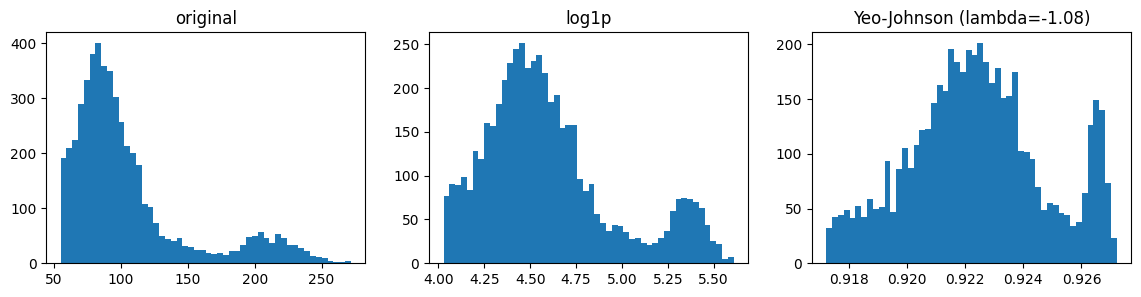

Numero de modas (KDE): original 2 | log1p 2 | Yeo-Johnson 2

% de pacientes por categoria de glucosa:
glucosa_cat
Normal            83.9000
Rango diabetico    8.5000
Elevada            7.6000
Name: proportion, dtype: float64


In [16]:
# [16] El caso dificil
# TODO: una de las tres variables mejora con el logaritmo pero NO queda simetrica.
#       Grafique su histograma original, logaritmico y Yeo-Johnson.
#       Reporte que porcentaje de pacientes cae en cada categoria clinica de esa variable.
g = df["avg_glucose_level"]
yj_g, lam_g = stats.yeojohnson(g)

fig, ax = plt.subplots(1, 3, figsize=(14, 3))
for a, (t, v) in zip(ax, {"original": g, "log1p": np.log1p(g), f"Yeo-Johnson (lambda={lam_g:.2f})": yj_g}.items()):
    a.hist(v, bins=50)
    a.set_title(t)
plt.show()

def modas(v):
    d = stats.gaussian_kde(v)(np.linspace(np.min(v), np.max(v), 500))
    return int(((d[1:-1] > d[:-2]) & (d[1:-1] > d[2:])).sum())
print("Numero de modas (KDE): original", modas(g), "| log1p", modas(np.log1p(g)), "| Yeo-Johnson", modas(yj_g))

print("\n% de pacientes por categoria de glucosa:")
print((df["glucosa_cat"].value_counts(normalize=True) * 100).round(1))

**Concluya variable por variable.** Para cada una de las tres numéricas: ¿transforma o no, y con
qué? Una de ellas **empeora** con el logaritmo: identifíquela y explique por qué. Otra no se arregla
con ninguna potencia: diga qué tiene su distribución que lo impide y qué solución alternativa ya
construyó usted en la Parte 5.

*Su respuesta:*

**Variable por variable:**

- **`age`: no transformo.** Ya es casi simétrica (asimetría −0.137) y **es la que empeora con el logaritmo**: `log1p` la lleva a −1.677 (`sqrt` a −0.786). Comprimir la cola derecha de una variable que ya es simétrica crea una cola izquierda. Yeo-Johnson tampoco mejora (−0.279, con λ = 0.86).
- **`bmi`: transformo con `log1p`.** La asimetría baja de 1.070 a 0.021, y Yeo-Johnson estima λ = −0.025, casi cero, que equivale al logaritmo; por eso uso `log1p`, más simple y sin parámetro que ajustar.
- **`avg_glucose_level`: no se arregla con ninguna potencia.** `log1p` mejora (1.572 → 0.889) pero no la deja simétrica; Yeo-Johnson (λ = −1.076) fuerza la asimetría a 0.085 apretando la cola de forma extrema, pero el histograma sigue con dos jorobas (el KDE encuentra 2 modas en el original, en `log1p` y en Yeo-Johnson). La distribución es **bimodal**: una población mayoritaria de glucosa normal (83.9 % por debajo de 140) y otra en la cola alta (7.6 % elevada y 8.5 % en rango diabético). Una potencia es una función monótona: estira o comprime el eje pero no puede fusionar dos modas. Además, una asimetría cercana a cero no garantiza simetría cuando hay dos modas.

**Solución alternativa que ya construí:** `glucosa_cat` (Parte 5), cuyos cortes clínicos de 140 y 200 mg/dL separan justo las dos poblaciones. La glucosa continua se conserva sin transformar, junto con las dos categorías elevadas.

---
## Parte 8 · Escalamiento (subtema 4.6)

             min    max  p95-p5  asimetria
Standard -2.4056 8.9031  3.2326     1.0699
MinMax    0.0000 1.0000  0.2859     1.0699
Robust   -1.9780 7.6154  2.7423     1.0699


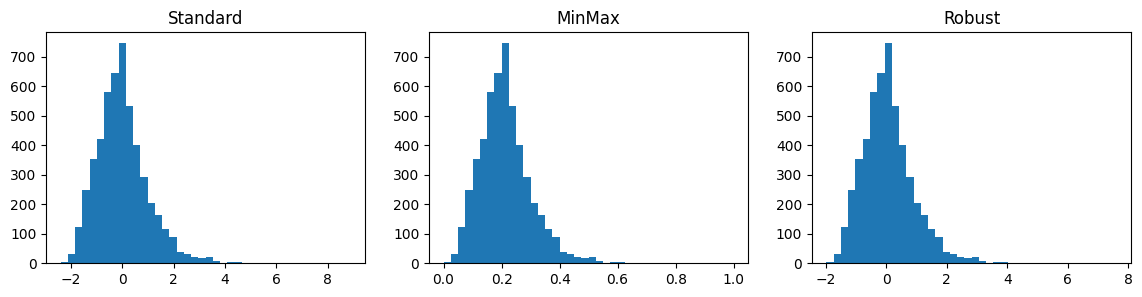

In [17]:
# [17] Comparacion de escaladores
# TODO: aplique StandardScaler, MinMaxScaler y RobustScaler a bmi.
#       Tabule minimo, maximo, amplitud del 90 % central (p95 - p5) y asimetria.
#       Grafique los tres histogramas resultantes.
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

escaladores = {"Standard": StandardScaler(), "MinMax": MinMaxScaler(), "Robust": RobustScaler()}
esc_bmi = {n: pd.Series(s.fit_transform(df[["bmi"]]).ravel()) for n, s in escaladores.items()}

print(pd.DataFrame({n: {"min": z.min(), "max": z.max(), "p95-p5": z.quantile(0.95) - z.quantile(0.05),
                        "asimetria": stats.skew(z)} for n, z in esc_bmi.items()}).T)

fig, ax = plt.subplots(1, 3, figsize=(14, 3))
for a, (n, z) in zip(ax, esc_bmi.items()):
    a.hist(z, bins=40)
    a.set_title(n)
plt.show()

**Explique dos cosas.** Primero: por qué la columna de asimetría es idéntica en los tres
escaladores. Segundo: cuál elige y cómo se conecta esa elección con la decisión que tomó sobre los
atípicos en la Parte 4. Diga además qué columnas **no** va a escalar y por qué.

*Su respuesta:*

**1. Por qué la asimetría es idéntica (1.0699) en los tres.** Los tres escaladores son transformaciones afines, z = (x − a) / b con b > 0. La asimetría es el tercer momento estandarizado, que no cambia al restar una constante ni al dividir entre una constante positiva. Un escalador cambia la posición y la unidad de medida, pero no la forma de la distribución. Para cambiar la asimetría hace falta una transformación no lineal (Parte 7).

**2. Escalador elegido: `RobustScaler`.** En la Parte 4 decidí **conservar** los atípicos (123 en `bmi` sobre 46.45, con máximo de 97.6, y 627 en glucosa). Con esos extremos presentes:
- `StandardScaler` usa media y desviación estándar, ambas infladas por la cola: el máximo queda a 8.90 desviaciones.
- `MinMaxScaler` toma el mínimo y el máximo (97.6) como límites, por lo que el 90 % central de los pacientes ocupa solo 0.286 del intervalo [0, 1].
- `RobustScaler` usa la mediana y el rango intercuartil, que no se mueven con los extremos: el 90 % central ocupa 2.74 unidades y los atípicos siguen visibles sin deformar al resto.

En la matriz final aplico primero `log1p` a `bmi` (Parte 7) y luego el escalador; sigo necesitando el robusto por la glucosa, que no se transforma y conserva su cola.

**Qué NO escalo:** `hypertension`, `heart_disease`, `bmi_faltante` y todas las columnas one-hot. Ya están en {0, 1}, escalarlas destruiría su interpretación (presencia o ausencia) y no aporta ventaja. Tampoco escalo el objetivo. Solo se escalan las tres continuas: `age`, `avg_glucose_level` y `bmi`.

---
## Parte 9 · Selección de funciones (subtema 4.1)

Llegó con más columnas de las que empezó. Decida cuáles se quedan aplicando **tres criterios
independientes**: varianza, relevancia y redundancia. Ninguno basta por sí solo.

In [18]:
# [18] Ensamblado de la matriz de modelado
# TODO: concatene las numericas, los indicadores, sus variables derivadas numericas
#       y la matriz one-hot en un DataFrame X. Separe el objetivo en y.
#       Reporte la forma y el listado de columnas.
DERIVADAS_NUM = ["n_comorbilidades", "bmi_faltante"]
X = pd.concat([df[NUMERICAS + INDICADOR + DERIVADAS_NUM], oh], axis=1)
y = df[OBJETIVO]
print("Forma de X:", X.shape, "| casos de ictus en y:", y.sum())
print(list(X.columns))

Forma de X: (5110, 32) | casos de ictus en y: 249
['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'n_comorbilidades', 'bmi_faltante', 'gender_Female', 'gender_Male', 'gender_Other', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'ever_married_Yes', 'Residence_type_Urban', 'imc_cat_Bajo peso', 'imc_cat_Normal', 'imc_cat_Obesidad', 'imc_cat_Sobrepeso', 'glucosa_cat_Elevada', 'glucosa_cat_Normal', 'glucosa_cat_Rango diabetico', 'grupo_edad_0-18', 'grupo_edad_18-40', 'grupo_edad_40-60', 'grupo_edad_60+']


In [19]:
# [19] Criterio 1 - varianza casi nula
# TODO: aplique VarianceThreshold(0.01) y liste las columnas descartadas.
#       Muestre las cinco varianzas mas bajas.
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(0.01).fit(X)
print("Descartadas por varianza < 0.01:", list(X.columns[~vt.get_support()]))
print("\nLas cinco varianzas mas bajas:")
print(X.var().sort_values().head(5))

Descartadas por varianza < 0.01: ['gender_Other', 'work_type_Never_worked']

Las cinco varianzas mas bajas:
gender_Other             0.0002
work_type_Never_worked   0.0043
bmi_faltante             0.0378
heart_disease            0.0511
imc_cat_Bajo peso        0.0616
dtype: float64


In [20]:
# [20] Criterio 2 - relevancia frente al objetivo
# TODO: calcule mutual_info_classif y la correlacion de Pearson de cada columna con y.
#       Presente ambas en una sola tabla ordenada por informacion mutua.
from sklearn.feature_selection import mutual_info_classif

discretas = [c not in NUMERICAS for c in X.columns]
mi = mutual_info_classif(X, y, discrete_features=discretas, random_state=SEED)
rel = pd.DataFrame({"info_mutua": mi, "pearson": X.corrwith(y)}, index=X.columns)
rel["rango_MI"] = rel["info_mutua"].rank(ascending=False)
rel["rango_pearson"] = rel["pearson"].abs().rank(ascending=False)
rel = rel.sort_values("info_mutua", ascending=False)
rel

,info_mutua,pearson,rango_MI,rango_pearson
age,0.0380,0.2453,1.0000,1.0000
grupo_edad_60+,0.0235,0.2366,2.0000,2.0000
n_comorbilidades,0.0111,0.1746,3.0000,3.0000
grupo_edad_18-40,0.0107,-0.1217,4.0000,9.0000
bmi,0.0097,0.0405,5.0000,21.0000
grupo_edad_0-18,0.0082,-0.1010,6.0000,12.0000
ever_married_Yes,0.0069,0.1083,7.0000,11.0000
glucosa_cat_Normal,0.0069,-0.1312,8.0000,7.0000
avg_glucose_level,0.0066,0.1319,9.0000,6.0000
bmi_faltante,0.0060,0.1412,10.0000,4.0000


In [21]:
# [21] Criterio 3 - redundancia entre predictores
# TODO: (a) calcule la correlacion de age con al menos tres columnas one-hot,
#       (b) la de cada variable continua con su version discretizada de la Parte 5,
#       (c) verifique si alguna de sus variables derivadas es una combinacion lineal
#           EXACTA de otras columnas de la matriz. Si la hay, es la misma trampa
#           de la Practica 7 y debe resolverse igual.
print("(a) Correlacion de age con las columnas one-hot (las 6 de mayor valor absoluto):")
print(X[oh.columns].corrwith(X["age"]).sort_values(key=abs, ascending=False).head(6).round(3))

print("\n(b) Variable continua vs su version discretizada (codigo ordinal):")
for c, k in [("age", "grupo_edad"), ("avg_glucose_level", "glucosa_cat"), ("bmi", "imc_cat")]:
    print(f"  {c:<18} vs {k:<12} r = {df[c].corr(pd.Series(df[k].cat.codes, index=df.index)):.3f}")

print("\n(c) n_comorbilidades == hypertension + heart_disease en todas las filas:",
      (X["hypertension"] + X["heart_disease"] == X["n_comorbilidades"]).all())
print("    Rango de X:", np.linalg.matrix_rank(X.to_numpy(dtype=float)), "de", X.shape[1], "columnas")

print("\nPares de predictores con |r| > 0.8:")
c = X.corr()
pares = c.where(np.triu(np.ones(c.shape, dtype=bool), 1)).stack()
print(pares[pares.abs() > 0.8].sort_values(key=abs, ascending=False).round(4))

(a) Correlacion de age con las columnas one-hot (las 6 de mayor valor absoluto):
grupo_edad_60+            0.7320
grupo_edad_0-18          -0.7040
ever_married_Yes          0.6790
work_type_children       -0.6340
imc_cat_Bajo peso        -0.3800
smoking_status_Unknown   -0.3780
dtype: float64

(b) Variable continua vs su version discretizada (codigo ordinal):
  age                vs grupo_edad   r = 0.962
  avg_glucose_level  vs glucosa_cat  r = 0.907
  bmi                vs imc_cat      r = 0.843

(c) n_comorbilidades == hypertension + heart_disease en todas las filas: True
    Rango de X: 26 de 32 columnas

Pares de predictores con |r| > 0.8:
gender_Female       gender_Male          -0.9996
avg_glucose_level   glucosa_cat_Normal   -0.8812
work_type_children  grupo_edad_0-18       0.8433
hypertension        n_comorbilidades      0.8193
dtype: float64


**Interprete los tres criterios.** Hay una variable cuya posición en el ranking cambia mucho según
se mida con información mutua o con correlación de Pearson: identifíquela y explique qué mide cada
criterio. Hay al menos dos columnas que son, en buena medida, la edad disfrazada: nómbrelas con su
coeficiente. Y decida el destino de **cada una** de las variables que usted construyó en la Parte 5:
diga cuáles conserva y con qué evidencia. No todas deberían sobrevivir.

*Su respuesta:*

**Variable cuya posición cambia: `bmi`.** Es la 5.ª por información mutua (0.0097) y la 21.ª por correlación de Pearson en valor absoluto (0.0405). Pearson mide solo asociación **lineal** (monótona); la información mutua mide **cualquier** dependencia. La relación entre `bmi` e ictus no es lineal ni monótona (0.3 %, 2.8 %, 7.0 % y 5.3 % por categoría de IMC), así que Pearson la subestima. Cautela: la información mutua de una variable continua se estima con vecinos más cercanos y es ruidosa con solo 249 casos positivos, por lo que la trato como indicio y no como prueba. En sentido contrario se mueve `bmi_faltante` (10.ª por MI, 4.ª por Pearson): es binaria y su efecto sí es lineal.

**La edad disfrazada:** `grupo_edad_60+` (r = 0.732), `grupo_edad_0-18` (r = −0.704), `ever_married_Yes` (r = 0.679) y `work_type_children` (r = −0.634). Las dos primeras son funciones de `age` por construcción; las otras dos son variables medidas de forma independiente que arrastran la edad (comparten menos de la mitad de la varianza con `age`).

**Reglas aplicadas en la celda [22]** (umbrales fijados por mí de forma explícita):
- Varianza: `VarianceThreshold(0.01)` descarta `gender_Other` (0.0002) y `work_type_Never_worked` (0.0043).
- Relevancia: descarto las columnas con información mutua < 0.0005 **y** correlación de Pearson < 0.02 en valor absoluto: `gender_Female`, `gender_Male`, `Residence_type_Urban`, `work_type_Private`, `work_type_Govt_job`, `smoking_status_smokes` y `smoking_status_never smoked`.
- Redundancia: la sección siguiente.

**Destino de las variables de la Parte 5:**
- **`n_comorbilidades` → se descarta.** Es combinación lineal **exacta** de `hypertension` y `heart_disease` (celda [21c]: la igualdad se cumple en las 5,110 filas), la misma trampa de la Práctica 7. Se resuelve igual: elimino la derivada y me quedo con sus componentes.
- **`grupo_edad` (4 columnas) → se descartan.** Su correlación con `age` es 0.962: es una función de una variable que ya está en la matriz, simétrica y sin transformar. Además, `grupo_edad_0-18` tiene r = 0.843 con `work_type_children`.
- **`imc_cat` (4 columnas) → se descartan.** `bmi` (con `log1p`) queda simétrica (0.021) y su relevancia (MI 0.0097) supera la de cualquiera de sus categorías (máximo 0.0026); además, `imc_cat_Obesidad` no supera el umbral de relevancia y la relación es no monótona.
- **`glucosa_cat` → conservo `Elevada` y `Rango diabetico`; descarto `Normal`.** Codifican el segundo modo que ninguna potencia repara (Parte 7) y las tasas son monótonas (3.6 %, 9.6 %, 12.9 %); `Rango diabetico` tiene MI de 0.0047 y Pearson de 0.114. `glucosa_cat_Normal` es el nivel complementario y tiene r = −0.881 con la glucosa.
- **`bmi_faltante` → se conserva** (Pearson 0.141, 4.ª posición).

**Por qué ninguno basta solo:** `n_comorbilidades` pasa varianza y relevancia (3.ª posición) y aun así sobra por redundancia; `bmi` parece irrelevante por Pearson y no lo es por MI; `gender_Other` se descarta antes de mirar su relevancia. Matriz final: 13 columnas, rango 13 de 13 (la dependencia lineal desapareció). Limitación: los criterios son univariados y no ven interacciones, por lo que podrían descartar columnas útiles junto con otra.

In [22]:
# [22] Matriz final
# TODO: elimine las columnas que sus tres criterios descartaron, escale las continuas
#       con el escalador que eligio en la Parte 8, y reporte la forma final
#       junto con las primeras filas.
# Criterio 1: varianza | Criterio 2: relevancia | Criterio 3: redundancia
c1 = list(X.columns[~vt.get_support()])
c2 = list(rel.index[(rel["info_mutua"] < 0.0005) & (rel["pearson"].abs() < 0.02)])
c3 = ["n_comorbilidades", "glucosa_cat_Normal"] + [c for c in X.columns if c.startswith(("grupo_edad_", "imc_cat_"))]
descartar = sorted(set(c1 + c2 + c3))
print("Descartadas:", descartar)

X_final = X.drop(columns=descartar).copy()
X_final["bmi"] = np.log1p(X_final["bmi"])                                   # decision de la Parte 7
continuas = ["age", "avg_glucose_level", "bmi"]
X_final[continuas] = RobustScaler().fit_transform(X_final[continuas])       # decision de la Parte 8

print("\nForma final:", X_final.shape, "| rango:", np.linalg.matrix_rank(X_final.to_numpy(dtype=float)))
X_final.head()

Descartadas: ['Residence_type_Urban', 'gender_Female', 'gender_Male', 'gender_Other', 'glucosa_cat_Normal', 'grupo_edad_0-18', 'grupo_edad_18-40', 'grupo_edad_40-60', 'grupo_edad_60+', 'imc_cat_Bajo peso', 'imc_cat_Normal', 'imc_cat_Obesidad', 'imc_cat_Sobrepeso', 'n_comorbilidades', 'smoking_status_never smoked', 'smoking_status_smokes', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private']

Forma final: (5110, 13) | rango: 13


,age,avg_glucose_level,bmi,hypertension,heart_disease,bmi_faltante,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,ever_married_Yes,glucosa_cat_Elevada,glucosa_cat_Rango diabetico
0,0.6111,3.7130,0.7952,0,1,0,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000
1,0.4444,2.9943,0.0859,0,0,1,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000
2,0.9722,0.3809,0.4271,0,1,0,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
3,0.1111,2.1535,0.6030,0,0,0,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000
4,0.9444,2.2319,-0.5060,1,0,0,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000


---
## Parte 10 · Tabla de decisiones

Complete una fila por cada columna del conjunto original. Ésta es la entrega que se califica con más
peso: es el resumen ejecutable de todo su criterio.

| Columna | Faltantes | Atípicos | Codificación | Transformación | Escalamiento | ¿Se conserva? |
|---|---|---|---|---|---|---|
| `id` | 0 nulos | No aplica | — | — | — | **No**: folio único (5,110 de 5,110), sin contenido clínico; se elimina en [6] |
| `gender` | 0 nulos | No aplica | One-hot (3 niveles; `if_binary` no elimina ninguno) | — | No (0/1) | **No**: `gender_Other` (1 paciente, varianza 0.0002) cae por varianza; Female y Male por relevancia (MI ≈ 0, r < 0.01) |
| `age` | 0 nulos | 0 atípicos (límites −29 a 115; máximo 82) | — (`grupo_edad` descartado por redundante) | Ninguna: asimetría −0.14; `log1p` la empeora a −1.68 | RobustScaler | **Sí** |
| `hypertension` | 0 nulos | No aplica | Ya es 0/1 | — | No | **Sí** |
| `heart_disease` | 0 nulos | No aplica | Ya es 0/1 | — | No | **Sí** |
| `ever_married` | 0 nulos | No aplica | Binaria: 1 columna (`ever_married_Yes`) | — | No | **Sí** (r = 0.68 con `age`; se vigila) |
| `work_type` | 0 nulos | No aplica | One-hot, 5 niveles | — | No | **Parcial**: se conservan `children` y `Self-employed`; se descartan `Never_worked` (22 pacientes, varianza 0.004), `Private` y `Govt_job` (MI ≈ 0) |
| `Residence_type` | 0 nulos | No aplica | Binaria: 1 columna | — | No | **No**: MI 0.0001 y r = 0.015 |
| `avg_glucose_level` | 0 nulos | 627 (> 169.36); se conservan (ictus 13.4 % vs 3.7 %) | Se añaden `glucosa_cat_Elevada` y `glucosa_cat_Rango diabetico` | Ninguna: bimodal, ninguna potencia la repara | RobustScaler | **Sí** (+ 2 columnas de `glucosa_cat`) |
| `bmi` | 201 (3.9 %): `bmi_faltante` + mediana por edad y sexo | 123 (> 46.45); se conservan (13 con `bmi` > 60, ninguno con ictus) | — (`imc_cat` descartada) | `log1p` (asimetría 1.07 → 0.02) | RobustScaler (sobre `log1p`) | **Sí** (+ `bmi_faltante`) |
| `smoking_status` | `Unknown` enmascarado: 1,544 (30.2 %); se conserva como categoría | No aplica | One-hot, 4 niveles | — | No | **Parcial**: se conservan `Unknown` y `formerly smoked`; se descartan `never smoked` y `smokes` (MI ≈ 0) |

---

## Preguntas de reflexión

Responda en dos o tres párrafos cada una, apoyándose en las cifras que produjo.

1. ¿Bajo qué condición dos filas con el mismo perfil clínico **sí** serían el mismo paciente? ¿Qué
   columna tendría que existir en el conjunto para poder afirmarlo?
2. Encontró una diferencia grande en la tasa del objetivo entre pacientes con y sin `bmi`
   registrado. ¿Qué mecanismo clínico podría explicarla y por qué la imputación sola es
   insuficiente?
3. La categoría enmascarada de `smoking_status` y los ceros de colesterol de la Práctica 7 son
   ambos faltantes disfrazados. Si les dio tratamientos distintos, justifique la diferencia.
4. Una de sus variables no se corrige con ninguna transformación de potencia. ¿Por qué? ¿Qué
   propiedad de su distribución lo impide?
5. Suponga que su modelo se despliega en un hospital donde el 40 % de los expedientes llega sin
   `bmi`. ¿Qué decisión de esta tarea cambiaría y cuál mantendría?
6. ¿Qué criterio distingue una discretización útil de una redundante? Apóyese en el destino que le
   dio a sus propias variables derivadas.

*Sus respuestas:*

**1. Mismo perfil clínico, ¿mismo paciente?** Solo si existe un identificador persistente de la persona (número de expediente, o un identificador anonimizado, que se repite entre registros del mismo individuo) junto con una columna de fecha o de visita. El identificador dice que es la misma persona; la fecha distingue una recaptura del mismo registro (duplicado) de un seguimiento (misma persona en otra visita, con otras mediciones). En este conjunto, `id` es un folio de registro: 5,110 folios únicos en 5,110 filas, por lo que no permite afirmar que dos filas sean la misma persona.

Sin ese identificador, la única evidencia es que coincidan todas las mediciones, y eso no ocurre: 0 duplicados exactos, 0 ignorando el folio, y 0 filas repetidas al añadir `bmi` y glucosa a la llave. Borrar por la llave clínica habría eliminado 2,677 filas (52.4 %), con 16 casos de ictus, y en 161 perfiles habría descartado un desenlace distinto.

**2. La diferencia en la tasa entre pacientes con y sin `bmi`.** La tasa de ictus es 19.9 % sin `bmi` y 4.3 % con `bmi`, y la edad media es 52.0 vs 42.9 años. El mecanismo clínico más plausible es que el `bmi` requiere pesar y medir al paciente, y el paciente grave, encamado o en urgencia por un evento cerebrovascular no se mide. El faltante depende de la gravedad y, por lo tanto, del desenlace.

La imputación por sí sola es insuficiente porque reemplaza el dato ausente por un valor típico (mediana por edad y sexo) y borra la señal: el paciente con `bmi` inventado se ve igual que uno medido. Además reduce artificialmente la dispersión (7.854 → 7.720). `bmi_faltante` conserva esa información y tiene una correlación de 0.141 con el objetivo (4.ª posición), mayor que la de `bmi` (0.040).

**3. Faltantes disfrazados: `Unknown` vs ceros de colesterol.** Los ceros de colesterol son un centinela numérico en una variable continua: un valor imposible que se reconoce, se convierte en NaN y se puede estimar con las mediciones observadas. `Unknown` vive en una variable nominal, no tiene un equivalente numérico que estimar, y su mecanismo es estructural: 90.0 % en `work_type = children` y 77.4 % en menores de 18 años, frente a cerca de 19-22 % en adultos.

Por eso los traté distinto. Imputar `Unknown` asignaría «fumador» o «no fumador» a niños y fabricaría datos en 1,544 pacientes (30.2 %); lo conservo como categoría propia (`smoking_status_Unknown`). Coincido en el fondo con el tratamiento de `bmi`: en ambos casos preservo la señal del faltante, ya sea con un indicador (`bmi_faltante`) o con la propia categoría.

**4. La variable que no se corrige con ninguna transformación de potencia.** Es `avg_glucose_level`. Su distribución es bimodal: la mayoría (83.9 %) está por debajo de 140 mg/dL y hay una segunda población en la cola alta (7.6 % elevada y 8.5 % en rango diabético). Las potencias son funciones monótonas que estiran o comprimen el eje, pero no pueden fusionar dos modas: `log1p` baja la asimetría de 1.572 a 0.889 y Yeo-Johnson (λ = −1.076) la baja a 0.085, pero el KDE sigue detectando 2 modas en las tres versiones.

La asimetría cercana a cero engaña porque solo mide el tercer momento, no la forma. Mi solución fue `glucosa_cat` con los cortes clínicos de 140 y 200 mg/dL, de la que conservo `Elevada` y `Rango diabetico`, sin transformar la glucosa continua y escalándola con `RobustScaler`.

**5. 40 % de expedientes sin `bmi` en el hospital de despliegue.** Cambiaría la estrategia de imputación y la confianza en `bmi_faltante`. Aquí el faltante afecta al 3.9 % de los pacientes y está ligado al desenlace (19.9 % vs 4.3 %); en un hospital donde el 40 % llega sin `bmi`, el faltante será más bien una cuestión de protocolo y no de gravedad, por lo que lo que el indicador aprendió no se trasladaría y podría inducir errores. Además, imputar por una mediana con 40 % de faltantes reduciría la varianza del orden de 40 %, mucho más que la caída de menos de 2 % que se observó aquí. Usaría una imputación más rica ajustada solo con datos de entrenamiento (o un modelo que tolere NaN) y revalidaría el indicador con datos de ese hospital.

Mantendría: no eliminar filas, la decisión de conservar los atípicos, `log1p` + `RobustScaler`, `Unknown` como categoría, la eliminación de `id` y las reglas explícitas de selección con sus umbrales (recalculando las métricas con los datos nuevos).

**6. Discretización útil vs redundante.** Una discretización es útil cuando añade algo que la variable continua no puede expresar en el modelo o cuando resuelve un problema que las transformaciones no pueden resolver; es redundante cuando es una función determinista de una variable continua que ya es utilizable. La correlación alta con la continua no distingue una de otra: las tres discretizaciones están altamente correlacionadas con su fuente (0.962, 0.907 y 0.843), como es de esperar por construcción.

Mis variables derivadas lo muestran. `glucosa_cat` es útil: la glucosa es bimodal y ninguna transformación la repara, y los cortes de 140 y 200 mg/dL separan las poblaciones (tasas de 3.6 %, 9.6 % y 12.9 %). `grupo_edad` (r = 0.962 con `age`, que es simétrica y ya está en la matriz) e `imc_cat` (`bmi` queda simétrica con `log1p` y su MI supera la de cualquiera de sus categorías) son redundantes, y `n_comorbilidades` es peor aún: una combinación lineal exacta de dos columnas presentes. Por eso solo sobreviven las categorías de `glucosa_cat`.